In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
dataset_path = "/content/drive/MyDrive/KULIAH/AITF"
print(os.listdir(dataset_path))

['train_qwen_rutilahu.jsonl', 'resized_img_448']


In [ ]:
!pip uninstall -y transformers
!pip install git+https://github.com/huggingface/transformers.git
!pip install accelerate bitsandbytes datasets peft pillow

Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
  Cloning https://github.com/huggingface/transformers.git to /tmp/pip-req-build-ansd1wu6
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-ansd1wu6
  Resolved https://github.com/huggingface/transformers.git to commit 42ff4f324f02448dcf03ea7d619f682b4e62c010
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for transformers: filename=transformers-5.3.0.dev0-py3-none-any.whl size=11304256 sha256=4af4f7931feed462d93b1d06856cd6591710c7a88d0bf2f826f8b79f508d7483
  Stored in directory: /tmp/pip-ephem-wheel-cache-m67hksrl/wheels/54/cb/3f/83103de5575c534436d6a4686686dead458238dfaf1147e98d
Successfully built transformers
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.0 MB/s eta 0:00:00


In [ ]:
import transformers
print(transformers.__version__)

5.3.0.dev0


In [ ]:
import torch
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from transformers import BitsAndBytesConfig
from datasets import load_dataset
from PIL import Image

In [ ]:
model_id = "Qwen/Qwen2-VL-2B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
)

model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id,
    device_map="auto",
    quantization_config=bnb_config
)

processor = AutoProcessor.from_pretrained(model_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

...

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
from datasets import load_dataset

dataset = load_dataset(
    "json",
    data_files="/content/drive/MyDrive/KULIAH/AITF/train_qwen_vl.jsonl"
)["train"]

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
from collections import defaultdict
from sklearn.model_selection import train_test_split

def get_label(example):

    text = example["messages"][1]["content"][0]["text"].lower()

    if "tidak_layak" in text:
        return "tidak_layak"
    if "perlu_perbaikan_sedang" in text:
        return "perlu_perbaikan_sedang"
    if "perlu_perbaikan_ringan" in text:
        return "perlu_perbaikan_ringan"
    if "layak" in text:
        return "layak"

    return "unknown"

image_to_label = {}

for item in dataset:

    img = item["messages"][0]["content"][0]["image"]
    img = img.split("/")[-1]

    label = get_label(item)

    image_to_label[img] = label

image_names = list(image_to_label.keys())
labels = [image_to_label[i] for i in image_names]

train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(
    image_names,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=42
)

val_imgs, test_imgs, val_labels, test_labels = train_test_split(
    temp_imgs,
    temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

def get_image(example):
    return example["messages"][0]["content"][0]["image"].split("/")[-1]

train_dataset = dataset.filter(lambda x: get_image(x) in train_imgs)
val_dataset = dataset.filter(lambda x: get_image(x) in val_imgs)
test_dataset = dataset.filter(lambda x: get_image(x) in test_imgs)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 144
Val: 30
Test: 32


In [ ]:
from collections import Counter

print("Train label:", Counter(train_labels))
print("Val label:", Counter(val_labels))
print("Test label:", Counter(test_labels))

Train label: Counter({'layak': 28, 'perlu_perbaikan_sedang': 18, 'tidak_layak': 15, 'perlu_perbaikan_ringan': 11})
Val label: Counter({'layak': 6, 'perlu_perbaikan_sedang': 4, 'tidak_layak': 3, 'perlu_perbaikan_ringan': 2})
Test label: Counter({'layak': 6, 'tidak_layak': 4, 'perlu_perbaikan_sedang': 4, 'perlu_perbaikan_ringan': 2})


In [ ]:
from PIL import Image
import os

def format_example(example):

    messages = example["messages"]

    image_path = messages[0]["content"][0]["image"]
    prompt = messages[0]["content"][1]["text"]
    response = messages[1]["content"][0]["text"]

    # ambil nama file saja
    image_path = os.path.basename(image_path)

    image = Image.open(
        f"/content/drive/MyDrive/KULIAH/AITF/resized_img_448/{image_path}"
    ).convert("RGB")

    return {
        "image": image,
        "prompt": prompt,
        "response": response
    }

train_dataset = train_dataset.map(format_example)
val_dataset = val_dataset.map(format_example)
test_dataset = test_dataset.map(format_example)

Map:   0%|          | 0/144 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

In [ ]:
def collate_fn(batch):

    texts = []
    images = []

    for item in batch:

        prompt = item["prompt"]
        response = item["response"]
        image = item["image"]

        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {"type": "text", "text": prompt}
                ]
            },
            {
                "role": "assistant",
                "content": [
                    {"type": "text", "text": response}
                ]
            }
        ]

        text = processor.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False
        )

        texts.append(text)
        images.append(image)

    inputs = processor(
        text=texts,
        images=images,
        padding=True,
        return_tensors="pt"
    )

    inputs["labels"] = inputs["input_ids"].clone()

    return inputs

In [ ]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj","v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 2,179,072 || all params: 2,211,164,672 || trainable%: 0.0985


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./qwen_rutilahu",

    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,

    num_train_epochs=20,          # besar → nanti early stop yang berhenti

    learning_rate=5e-5,
    logging_steps=10,

    eval_strategy="steps",
    eval_steps=50,

    save_strategy="steps",
    save_steps=50,
    save_total_limit=2,

    load_best_model_at_end=True,  # otomatis load model terbaik
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    fp16=True,
    remove_unused_columns=False,

    report_to="none"
)

In [ ]:
from transformers import Trainer, EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=collate_fn,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

In [ ]:
trainer.train()

Step,Training Loss,Validation Loss
50,8.612132,8.318345
100,6.683951,6.999345


Step,Training Loss,Validation Loss
50,8.612132,8.318345
100,6.683951,6.999345
150,6.063865,6.597685
200,5.913001,6.344349
250,5.706212,6.184003
300,5.505102,6.096779
350,5.626061,6.047994
400,5.355584,6.016109
450,5.550549,5.995279
500,5.323802,5.981329


TrainOutput(global_step=720, training_loss=6.163213464948866, metrics={'train_runtime': 1787.7508, 'train_samples_per_second': 1.611, 'train_steps_per_second': 0.403, 'total_flos': 1.313197829916672e+16, 'train_loss': 6.163213464948866, 'epoch': 20.0})

In [ ]:
!pip install scikit-learn

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch
import re

In [ ]:
import re

def extract_classification(text):

    text = text.lower()

    patterns = {
        "tidak_layak": r"tidak[_ ]?layak",
        "perlu_perbaikan_sedang": r"perlu[_ ]?perbaikan[_ ]?sedang",
        "perlu_perbaikan_ringan": r"perlu[_ ]?perbaikan[_ ]?ringan",
        "layak": r"\blayak\b"
    }

    for label, pattern in patterns.items():
        if re.search(pattern, text):
            return label

    return "unknown"

In [ ]:
def get_ground_truth(example):

    text = example["response"].lower()

    if "tidak_layak" in text:
        return "tidak_layak"

    if "perlu_perbaikan_sedang" in text:
        return "perlu_perbaikan_sedang"

    if "perlu_perbaikan_ringan" in text:
        return "perlu_perbaikan_ringan"

    if "layak" in text:
        return "layak"

    return "unknown"

In [ ]:
y_true = []
y_pred = []

model.eval()

for item in test_dataset:

    image = item["image"]
    prompt = item["prompt"]

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": prompt}
            ]
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = processor(
        text=[text],
        images=[image],
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_new_tokens=100
        )

    result = processor.batch_decode(
        outputs,
        skip_special_tokens=True
    )[0]

    pred = extract_classification(result)
    true = get_ground_truth(item)

    if pred != "unknown":
        y_pred.append(pred)
        y_true.append(true)

In [ ]:
labels = [
    "layak",
    "perlu_perbaikan_ringan",
    "perlu_perbaikan_sedang",
    "tidak_layak"
]

print("Accuracy:")
print(accuracy_score(y_true, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred, labels=labels))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=labels))

Accuracy:
0.5

Confusion Matrix:
[[0 1 2 0]
 [0 1 1 0]
 [0 0 5 1]
 [0 0 3 2]]

Classification Report:
                        precision    recall  f1-score   support

                 layak       0.00      0.00      0.00         3
perlu_perbaikan_ringan       0.50      0.50      0.50         2
perlu_perbaikan_sedang       0.45      0.83      0.59         6
           tidak_layak       0.67      0.40      0.50         5

              accuracy                           0.50        16
             macro avg       0.41      0.43      0.40        16
          weighted avg       0.44      0.50      0.44        16



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


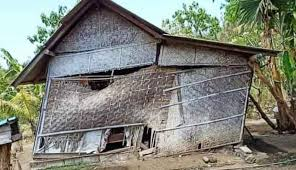

In [ ]:
image_name = '/content/drive/MyDrive/KULIAH/AITF/test/tidak-layak.jpeg'

from PIL import Image

image = Image.open(image_name).convert("RGB")
image

#Prompt untuk analisis rumah

In [ ]:
prompt = f"""
Analisis kondisi rumah pada gambar.

Ikuti format output berikut secara tepat:

Analisis singkat (gambar: {image_name}):
Atap: <kondisi atap>
Dinding: <kondisi dinding>
Lantai: <kondisi lantai>
Material bangunan: <jenis material>

Klasifikasi akhir: <layak | perlu_perbaikan_ringan | perlu_perbaikan_sedang | tidak_layak>

Alasan: <jelaskan alasan klasifikasi berdasarkan kondisi bangunan>
"""

#Buat Input ke model

In [ ]:
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": prompt}
        ]
    }
]

text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

NameError: name 'processor' is not defined

#convert ke tensor

In [ ]:
inputs = processor(
    text=[text],
    images=[image],
    return_tensors="pt"
).to(model.device)

#generate output

In [ ]:
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=120
    )

#decode hasil

In [ ]:
generated_ids = outputs[0][inputs["input_ids"].shape[1]:]

result = processor.decode(
    generated_ids,
    skip_special_tokens=True
)

print(result)

Analisis singkat (gambar: /content/drive/MyDrive/KULIAH/AITF/test/layak.jpeg):
Atap: Lantai menggunakan kayu
Dinding: Atas menggunakan kayu
Lantai: Lantai menggunakan kayu
Material bangunan: Kayu
Klasifikasi akhir: Perlu_perbaikan_ringan
Alasan: Atap dan dinding menggunakan kayu, yang membutuhkan perbaukan untuk mempertahankan kestabilan dan kebersihan.


In [ ]:
trainer.save_model("/content/drive/MyDrive/model_rutilahu")